In [1]:
import io
import numpy as np
import pandas as pd
from scipy import optimize
import matplotlib.pyplot as plt
from scifit import solvers

In [2]:
data = pd.read_csv(io.StringIO("""x0,y
410.0,73.06578085929756
25.0,205.29417389522575
72.0,110.48653325137172
51.0,168.52111516008628
15.0,119.75684720989004
72.0,164.46280991735537
73.0,145.53126751391522
36.0,161.41429319490925
40.0,219.91735537190084
190.0,89.18717804003897
21.0,203.3350571291969
47.0,170.12964176670877
21.0,197.1020714822368
18.0,96.43526170798899
53.0,117.55060034305319
50.0,189.89358650365415
43.0,179.03132807995385
863.0,69.63888057656149
71.0,131.42730764753813
40.0,205.2892561983471
65.0,131.3857292219426
401.0,133.81511047189076
50.0,115.65603442387814
58.0,151.99074870050802
50.0,165.8640803223824
21.0,210.87942861045792
236.0,124.21734182739671
53.0,180.11451429366744
12.0,320.77043917765184
36.0,244.3526170798898
25.0,202.41568198893515
21.0,184.03895128162597
29.0,165.64724945771087
25.0,218.1818181818182
72.0,161.8457300275482
130.0,107.38232466256511
84.0,177.52397865095088
38.0,57.524112172378224
50.0,168.132777815723
25.0,202.41568198893515
21.0,244.3978260657449
48.0,168.3167133392528
200.0,122.8403797554812
37.0,167.84185838731295
83.0,173.75445583988846
13.0,315.835929660122
11.0,314.47181327653976
32.0,203.68741889215215
200.0,123.96694214876034
39.0,110.59353869271226
39.0,190.81504521023686
40.0,235.53719008264466
37.0,181.71111484409758
25.0,215.55576804863057
40.0,235.53719008264466"""))

In [3]:
#data["y"] -= 7.71197502e+01

In [4]:
def model_1(x, a, b, c):
    return a + b * x**c


def model_2(x, d, e, f):
    return d + e * (x**f - 1) / f

In [5]:
class Solver1(solvers.FitSolver1D):
    @staticmethod
    def model(x, a, b, c):
        return a + b * x[:,0] ** c

In [6]:
class Solver2(solvers.FitSolver1D):
    @staticmethod
    def model(x, d, e, f):
        return d + e * (x[:,0] ** f - 1) / f

In [7]:
xlin = np.linspace(data.x0.min(), data.x0.max(), 200)

In [8]:
popt1, pcov1 = optimize.curve_fit(model_1, data.x0, data.y, maxfev=5000)

In [9]:
model1b = Solver1()
sol1b = model1b.fit(data, p0=popt1)

In [10]:
model1 = Solver1()
sol1 = model1.fit(data, p0=[100, 1000, -1])

In [11]:
sol1["parameters"]

array([ 7.71197502e+01,  7.48346332e+02, -5.59037369e-01])

In [12]:
y1lin = model1.predict(xlin.reshape(-1, 1))

In [13]:
model2 = Solver2()
sol2 = model2.fit(data)

In [14]:
y2lin = model2.predict(xlin.reshape(-1, 1))

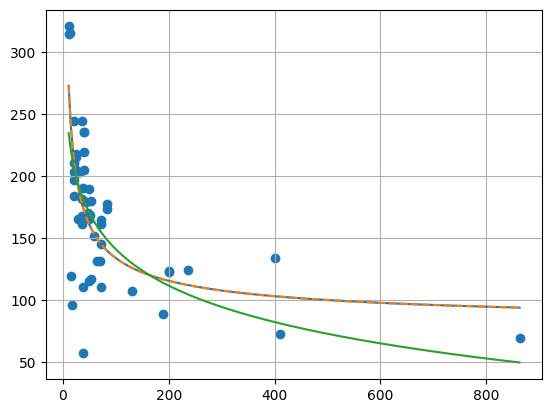

In [15]:
fig, axe = plt.subplots()
axe.scatter(data.x0, data.y)
axe.plot(xlin, y1lin)
axe.plot(xlin, y2lin, "--")
axe.plot(xlin, model_1(xlin, *popt1))
axe.grid()

array([[<Axes: ylabel='$\\beta_{2}$'>, <Axes: >],
       [<Axes: xlabel='$\\beta_{1}$', ylabel='$\\beta_{3}$'>,
        <Axes: xlabel='$\\beta_{2}$'>]], dtype=object)

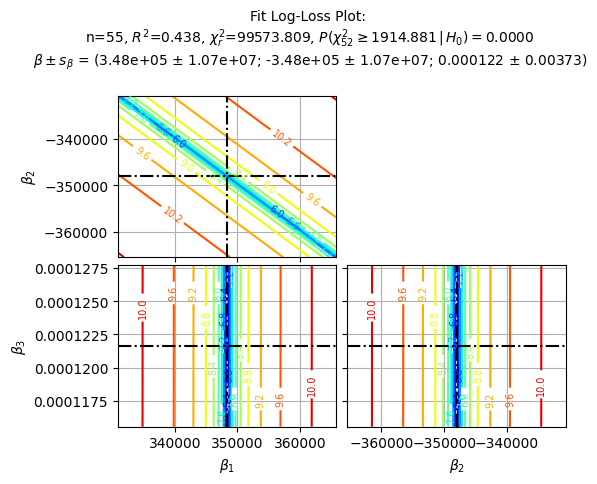

In [16]:
model1b.plot_loss(log_loss=True, factor=.5)

array([[<Axes: ylabel='$\\beta_{2}$'>, <Axes: >],
       [<Axes: xlabel='$\\beta_{1}$', ylabel='$\\beta_{3}$'>,
        <Axes: xlabel='$\\beta_{2}$'>]], dtype=object)

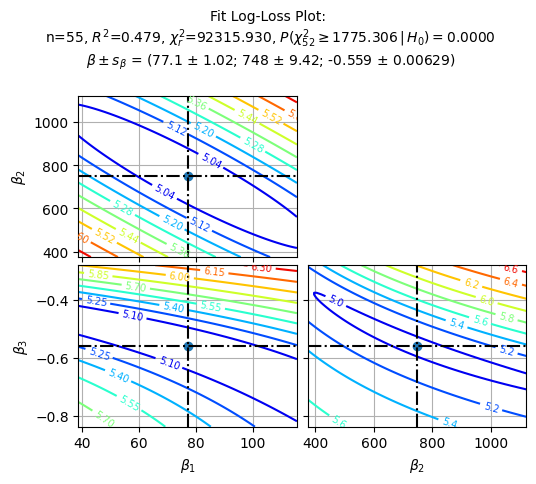

In [17]:
model1.plot_loss(log_loss=True)

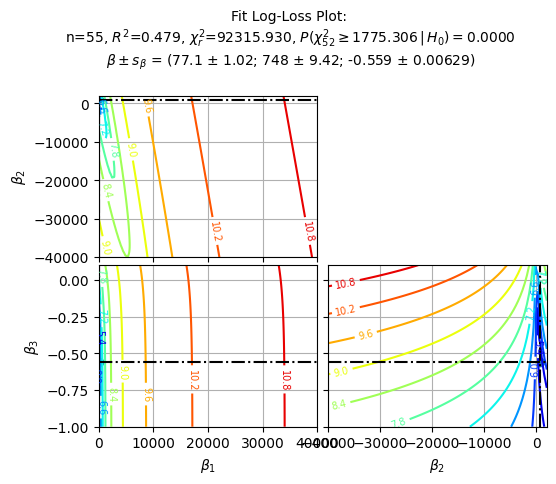

In [18]:
axes = model1.plot_loss(log_loss=True, domains=pd.DataFrame({"min": [0,-40000,-1], "max": [40000, 2000, 0.1]}).T)
axes[0][0].scatter(popt1[0], popt1[1])

array([[<Axes: ylabel='$\\beta_{2}$'>, <Axes: >],
       [<Axes: xlabel='$\\beta_{1}$', ylabel='$\\beta_{3}$'>,
        <Axes: xlabel='$\\beta_{2}$'>]], dtype=object)

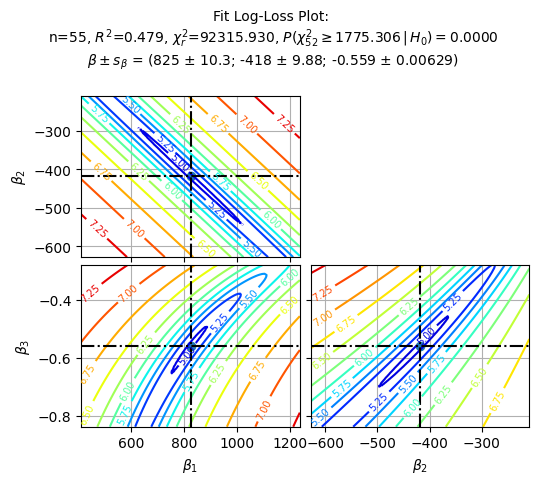

In [19]:
model2.plot_loss(log_loss=True)